<a href="https://colab.research.google.com/github/kylermurphy/contigo_edr/blob/main/Orekit_EDR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting Up CondaForge

We need conda to load specific libraries, this can be done with ```condacolab``` via pip, however this installs python 3.11 which does match Colabs python version.

To circumvent this we install the latest version of [miniforge](https://github.com/conda-forge/miniforge) which provides python 3.12 in the base environment using ```install_from_url()``` as opposed to the default ```install()```.

**Note** after running ```condacolab.install_from_url(url)``` the Colab kernel will be restarted and you may see a crash warning but everything should be fine.
**This means you can't use ```Run All``` initially. It can be used after the kernel restarts.**


In [ ]:
!python --version

Python 3.12.12


In [ ]:
# miniforge with python 3.12
installer_url='https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh'

In [ ]:
# find the system version of python
# and check if the conda version of
# python is installed
sys_python = !python --version
sys_python = sys_python[0].split(' ')[1]

try:
  conda_list = !conda list python
  conda_python = [x.split()[1] for x in conda_list if x.split()[0] == 'python'][0]

  if conda_python == sys_python:
    python_match = True

  print('Conda and System Python Match')
  install_conda = False
except:
  print('conda not installed')
  conda_python = None
  install_conda = True


Conda and System Python Match


In [ ]:
if install_conda == True:
  print('Installing Conda')
  !pip install -q condacolab
  import condacolab
  condacolab.install_from_url(installer_url)
else:
  import condacolab
  condacolab.check()

✨🍰✨ Everything looks OK!


In [ ]:
# import again because the kernel was restarted
import condacolab
condacolab.check()

✨🍰✨ Everything looks OK!


In [ ]:
#check if we have it installed to save some time
ore_conda = !conda list orekit
try:
  ore_conda = [x.split()[0] for x in ore_conda if x.split()[0] == 'orekit'][0]
  print('Orekit already installed')
except:
  print('Installing Orekit')
  !mamba -q -y install orekit -c conda-forge


Orekit already installed


In [ ]:
import pandas as pd
import zipfile
import orekit
vm = orekit.initVM()
print ('Java version:',vm.java_version)
print ('Orekit version:', orekit.VERSION)

Java version: 1.8.0_472
Orekit version: 13.1


# Setting up Orekit

Orekit uses a default potential file for Earth's gravity. We want to replace this either WGM86, which GMAT uses, or EIGEN-2S, which the Colorado group uses ([Sutton et al. 2021](https://doi.org/10.1029/2021SW002736), [Fitzpatrick et al. 2025](https://doi.org/10.1029/2024EA003898)).

Before setting up Orekit we download the Orekit data file delete the existing potential file and replace it with ours ```pot_file```.

We also download Swarm POD data.

These files are stored on the ```contigo_edr``` github repository for easy access.




In [ ]:
base_url = 'https://raw.githubusercontent.com/kylermurphy/contigo_edr/refs/heads/main/data/'
pot_file = 'EIGEN-2.gfc'
dat_file = 'ESA_pod.hdf'

In [ ]:
!wget {base_url}{pot_file}
!wget {base_url}{dat_file}

--2026-02-10 17:02:04--  https://raw.githubusercontent.com/kylermurphy/contigo_edr/refs/heads/main/data/EIGEN-2.gfc
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589963 (576K) [application/octet-stream]
Saving to: ‘EIGEN-2.gfc.1’

EIGEN-2.gfc.1       100%[===================>] 576.14K  --.-KB/s    in 0.007s  

2026-02-10 17:02:05 (76.8 MB/s) - ‘EIGEN-2.gfc.1’ saved [589963/589963]

--2026-02-10 17:02:05--  https://raw.githubusercontent.com/kylermurphy/contigo_edr/refs/heads/main/data/ESA_pod.hdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 

In [ ]:
import pandas as pd
import zipfile
from orekit.pyhelpers import setup_orekit_curdir, download_orekit_data_curdir
download_orekit_data_curdir()

# remove the gfc file in the orekit data
# and add the pot_file
if pot_file:
  !zip -d /content/orekit-data.zip orekit-data-main/Potential/eigen-6s.gfc
  with zipfile.ZipFile('/content/orekit-data.zip', 'a', compression=zipfile.ZIP_DEFLATED) as zip_ref:
      zip_ref.write(f'/content/{pot_file}', arcname=f'orekit-data-main/Potential/{pot_file}')

  zip_filename = '/content/orekit-data.zip'
  zip_string = 'Potential'

  with zipfile.ZipFile(zip_filename, 'r') as archive:
      zip_files = archive.namelist()

  zip_filtered = [item for item in zip_files if zip_string in item]
  print(zip_filtered)

setup_orekit_curdir()

deleting: orekit-data-main/Potential/eigen-6s.gfc
['orekit-data-main/Potential/', 'orekit-data-main/Potential/EIGEN-2.gfc']


In [ ]:
# load what we need from orekit
from org.orekit.frames import FramesFactory, TopocentricFrame, StaticTransform
from org.orekit.time import TimeScalesFactory, AbsoluteDate, DateComponents, TimeComponents
from org.orekit.utils import IERSConventions, Constants, PVCoordinates, PVCoordinatesProvider, AbsolutePVCoordinates
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel
from org.hipparchus.geometry.euclidean.threed import Vector3D
from org.orekit.forces.gravity import ThirdBodyAttraction
from org.orekit.bodies import CelestialBodies, CelestialBodyFactory
from org.orekit.orbits import CartesianOrbit
from org.orekit.propagation import SpacecraftState


from math import radians, pi, degrees
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# get the potential for the spacecraft location
sw_d = pd.read_hdf('/content/ESA_pod.hdf')


## Calculate Gravitational Potential

**Note** we are using a time indpendent gravatational potential (some of the ICGEM files can be time dependent).

In [ ]:
# setup the gravity field calculation
lmax = 100
pv = Vector3D(-2469.855031*1000, -6425.484436*1000, -92.213577*1000)
utc = TimeScalesFactory.getGPS()
#16 Jan 2018 23:55:01.000
Epoch_date = AbsoluteDate(0, 1, 16, 23, 55, 1.0, utc)

gravityProvider = GravityFieldFactory.getNormalizedProvider(lmax, lmax)
gravityfield = HolmesFeatherstoneAttractionModel(
    FramesFactory.getITRF(IERSConventions.IERS_2010, False), gravityProvider)

In [ ]:
# setup the orekit vectors we need
pos_ecef = [Vector3D(x*1000., y*1000., z*1000.)
            for x, y, z in
            zip(sw_d['x'], sw_d['y'], sw_d['z'])]

vel_ecef = [Vector3D(x*1000., y*1000., z*1000.)
            for x, y, z in
            zip(sw_d['vx'], sw_d['vy'], sw_d['vz'])]

epoch = [AbsoluteDate(dt.year, dt.month, dt.day, dt.hour, dt.minute, float(dt.second), utc)
          for dt in sw_d['DateTime']]

In [ ]:
# get the gravity potential at each spacecraft location
grav_pot = [gravityfield.value(ed, pos_v, gravityProvider.mu)
            for ed, pos_v in
            zip(epoch, pos_ecef)]

grav_pot = np.array(grav_pot)

## Calculate SC ECI State and Acceleration due to Earth

In [ ]:
# convert the ESA POD ECEF to ECI
# we'll use the ECI coords to derive
# the Earth acceleration and later the
# 3rd body accelerations of the sun and moon
earth_eci_a = []
eci_pos = []
eci_vel = []
# Frame for that we are using
# These could be moved above as they are constant
eci = FramesFactory.getEME2000()
ecef = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
for pos, vel, ed in zip(pos_ecef, vel_ecef, epoch):
  pv = PVCoordinates(pos, vel)
  # get the transform to ECI
  ecef2eci = ecef.getKinematicTransformTo(eci, ed)
  eci_pv = ecef2eci.transformOnlyPV(pv)

  # create an orbit and spacecraft state
  orbit = CartesianOrbit(eci_pv, eci, ed, gravityProvider.mu)
  state = SpacecraftState(orbit)
  # get the ECI acceleration
  # this is just the perturbing acceleration
  earth_acc  = gravityfield.acceleration(state, gravityProvider.mu)
  earth_apert = np.array([earth_acc.x, earth_acc.y, earth_acc.z])
  eci_p = [eci_pv.getPosition().x, eci_pv.getPosition().y, eci_pv.getPosition().z]
  eci_p = np.array(eci_p)
  eci_v = [eci_pv.getVelocity().x, eci_pv.getVelocity().y, eci_pv.getVelocity().z]
  eci_v = np.array(eci_v)
  # get the full accleration
  earth_tot = -1*gravityProvider.mu*eci_p/np.linalg.norm(eci_p)**3 + earth_apert
  earth_eci_a.append(earth_tot)
  eci_pos.append(eci_p)
  eci_vel.append(eci_v)

eci_pos = np.array(eci_pos)
eci_vel = np.array(eci_vel)
eci_earth_a = np.array(earth_eci_a)

In [ ]:
## check that we have similar acceleration to GMAT
gmat_earth = np.linalg.norm(sw_d[['eg_x','eg_y','eg_z']].to_numpy(), axis=1)
gmat_earth = gmat_earth*1000.
ore_earth = np.linalg.norm(eci_earth_a, axis=1)

print(np.allclose(gmat_earth,ore_earth))

True


## Calculate Third Body Accelerations

Orekit derives the third body accelerations in ECI coordinates; however, we want them in ECEF coordinates.

Below we use Orekit to derive the accelerations as well as the function ```cb3bp_acc``` which uses:


This way we can compare the two methods to derive acceleration in ECI coordinates but also use ```cb3bp_acc``` to derive acceleration in ECEF coordinates.

In [ ]:
# function to calculate acceleration
# resulting from third body perturbations
def cb3bp_acc(cb_pv, sat_pos, mu):

  cb3bp_p = cb_pv.getPosition()
  cbr3r1 = cb3bp_p.subtract(sat_pos)
  cb_x1 = np.array([cbr3r1.x, cbr3r1.y, cbr3r1.z])/cbr3r1.getNorm()**3
  cb_x2 = np.array([cb3bp_p.x, cb3bp_p.y, cb3bp_p.z])/cb3bp_p.getNorm()**3

  acc = mu*(cb_x1-cb_x2)

  return acc

In [ ]:
sn_ai = []
mn_ai = []
sn_af = []
mn_af = []

sn_pfx = []
sn_pfy = []
sn_pfz = []
mn_pfx = []
mn_pfy = []
mn_pfz = []

eci = FramesFactory.getEME2000()
ecef = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
sun_cb = CelestialBodyFactory.getSun()
moon_cb = CelestialBodyFactory.getMoon()

for ed, eci_x, eci_y, eci_z, ecf_x, ecf_y, ecf_z in \
  zip(epoch, sw_d['eci_x']*1000, sw_d['eci_y']*1000, sw_d['eci_z']*1000,
      sw_d['x']*1000, sw_d['y']*1000, sw_d['z']*1000):

  # calculate accelerations in eci
  sat_eci = Vector3D(eci_x, eci_y, eci_z)
  sun_eci = sun_cb.getPVCoordinates(ed, eci)
  moon_eci = moon_cb.getPVCoordinates(ed, eci)

  sn_acc_eci = cb3bp_acc(sun_eci, sat_eci, mu=Constants.JPL_SSD_SUN_GM)
  mn_acc_eci = cb3bp_acc(moon_eci, sat_eci, mu=Constants.JPL_SSD_MOON_GM)

  # calculate accelerations in ecef
  eci_to_ecef_transform = eci.getKinematicTransformTo(ecef, ed)
  sat_ecef = Vector3D(ecf_x, ecf_y, ecf_z)

  sun_ecef = eci_to_ecef_transform.transformOnlyPV(sun_eci)
  moon_ecef = eci_to_ecef_transform.transformOnlyPV(moon_eci)

  sn_acc_ecef = cb3bp_acc(sun_ecef, sat_ecef, mu=Constants.JPL_SSD_SUN_GM)
  mn_acc_ecef = cb3bp_acc(moon_ecef, sat_ecef, mu=Constants.JPL_SSD_MOON_GM)

  sn_ai.append(sn_acc_eci)
  mn_ai.append(mn_acc_eci)

  sn_af.append(sn_acc_ecef)
  mn_af.append(mn_acc_ecef)

  sn_pfx.append(sun_ecef.getPosition().x)
  sn_pfy.append(sun_ecef.getPosition().y)
  sn_pfz.append(sun_ecef.getPosition().z)

  mn_pfx.append(moon_ecef.getPosition().x)
  mn_pfy.append(moon_ecef.getPosition().y)
  mn_pfz.append(moon_ecef.getPosition().z)



In [ ]:
# check that the derived accelerations
# are similar to those from gmat
sn_ai = np.array(sn_ai)
sn_af = np.array(sn_af)
mn_ai = np.array(mn_ai)
mn_af = np.array(mn_af)


print(np.allclose(sn_ai, sw_d[['sg_x','sg_y','sg_z']].to_numpy()*1000., rtol=0.001))
print(np.allclose(mn_ai, sw_d[['mg_x','mg_y','mg_z']].to_numpy()*1000., rtol=0.001))

True
True


In [ ]:
print(Constants.JPL_SSD_SUN_GM)
print(Constants.JPL_SSD_MOON_GM)

1.32712440017987e+20
4902798458429.647


Let try and get the Energy Dissapation Rate

In [ ]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import cumulative_simpson

In [ ]:
ore_d = pd.DataFrame({'eci_x':eci_pos[:,0], 'eci_y':eci_pos[:,1], 'eci_z':eci_pos[:,2],
                      'eci_vx':eci_vel[:,0], 'eci_vy':eci_vel[:,1], 'eci_vz':eci_vel[:,2],
                      'eci_sn_ax':sn_ai[:,0], 'eci_sn_ay':sn_ai[:,1], 'eci_sn_az':sn_ai[:,2],
                      'eci_mn_ax':mn_ai[:,0], 'eci_mn_ay':mn_ai[:,1], 'eci_mn_az':mn_ai[:,2],
                      'ecef_sn_ax':sn_af[:,0], 'ecef_sn_ay':sn_af[:,1], 'ecef_sn_az':sn_af[:,2],
                      'ecef_mn_ax':mn_af[:,0], 'ecef_mn_ay':mn_af[:,1], 'ecef_mn_az':mn_af[:,2],
                      'ecef_sn_px':sn_pfx, 'ecef_sn_py':sn_pfy, 'ecef_sn_pz':sn_pfz,
                      'ecef_mn_px':mn_pfx, 'ecef_mn_py':mn_pfy, 'ecef_mn_pz':mn_pfz,
                      'earth_gp':grav_pot})

ore_d['DateTime'] = sw_d['DateTime']
ore_d[['ecef_x','ecef_y','ecef_z']] = sw_d[['x','y','z']]
ore_d[['ecef_vx,','ecef_vy','ecef_vz']] = sw_d[['vx','vy','vz']]

ore_d.columns


Index(['eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy', 'eci_vz', 'eci_sn_ax',
       'eci_sn_ay', 'eci_sn_az', 'eci_mn_ax', 'eci_mn_ay', 'eci_mn_az',
       'ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az', 'ecef_mn_ax', 'ecef_mn_ay',
       'ecef_mn_az', 'ecef_sn_px', 'ecef_sn_py', 'ecef_sn_pz', 'ecef_mn_px',
       'ecef_mn_py', 'ecef_mn_pz', 'earth_gp', 'DateTime', 'ecef_x', 'ecef_y',
       'ecef_z', 'ecef_vx,', 'ecef_vy', 'ecef_vz'],
      dtype='object')

In [ ]:
# this is our x-axis for integrating
int_sec = (pd.DatetimeIndex(sw_d['DateTime']).to_julian_date()*86400.).to_numpy()
int_sec = int_sec-int_sec.min()

ecef_v = sw_d[['vx','vy','vz']].to_numpy()*1000
ecef_r = sw_d[['x','y','z']].to_numpy()*1000
ecef_xy2 = (sw_d['x'].to_numpy()*1000)**2+(sw_d['y'].to_numpy()*1000)**2
ecef_v2 = (ecef_v*ecef_v).sum(axis=1)
w2 = Constants.WGS84_EARTH_ANGULAR_VELOCITY**2

eci_v = sw_d[['eci_vx','eci_vy','eci_vz']].to_numpy()*1000
srp_a = sw_d[['srp_x','srp_y','srp_z']].to_numpy()*1000

a1 = (sn_af*ecef_v).sum(axis=1)
a2 = (mn_af*ecef_v).sum(axis=1)
a3 = (srp_a*eci_v).sum(axis=1) # this is a fudge factor that we can fix

# denomenator
B = (3.5)*(1.1)/(4.3e+02)
ecef_v3 = np.linalg.norm(ecef_v, axis=1)**3

In [ ]:
edr = ecef_v2/2. - w2*ecef_xy2/2. - grav_pot - \
      cumulative_trapezoid(a1, int_sec, initial=0) - \
      cumulative_trapezoid(a2, int_sec,initial=0) - \
      cumulative_trapezoid(a3, int_sec,initial=0)
edr = edr - ecef_v2[0]/2. - w2*ecef_xy2[0]/2. - grav_pot[0]

denom = B*cumulative_trapezoid(ecef_v3, int_sec,initial=0)

sw_d['edr'] = edr
sw_d['denom'] = denom

In [ ]:
gmat_edr = pd.read_hdf('/content/efd_esa_pod.hdf')
gmat_edr.columns
gmat_edr['tol_efd'] = gmat_edr['tol_efd']/(1000.**3)
gmat_edr['efd_2'] = gmat_edr['efd_2']/(1000.**3)
gmat_edr['efd_1'] = gmat_edr['efd_1']/(1000.**3)

<Axes: xlabel='DateTime'>

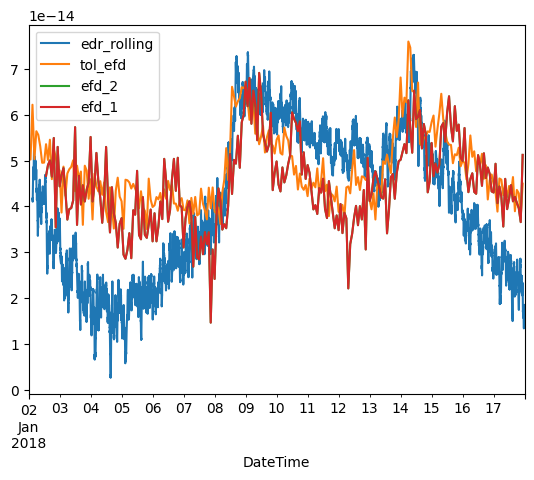

In [ ]:
sw_d['edr_rolling'] = sw_d['edr'].rolling(540).mean()
ti = int(90*60/10.)
efd = pd.DataFrame()
efd['edr_rolling'] = -2*(sw_d['edr_rolling'].shift(ti)-sw_d['edr_rolling'])/(sw_d['denom'].shift(ti)-sw_d['denom'])
efd['DateTime'] = sw_d['DateTime'].copy()
efd = efd.dropna()
ax = efd.plot(x='DateTime',y='edr_rolling')
gmat_edr.plot(x='DateTime',y=['tol_efd','efd_2','efd_1'],ax=ax)